# Recap - The Cars Dataset(Arabalar Veri Kümesi)

In [95]:
# 1 - DATA MANIPULATION
import pandas as pd
import numpy as np

# 2 - DATA VISUALISATION
import matplotlib.pyplot as plt
import seaborn as sns

# 3 - STATISTICS
from statsmodels.graphics.gofplots import qqplot

# 4 - MACHINE LEARNING

## 4.1 - Preprocessing

### 4.1.1 - Scalers
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler

### 4.1.2 - Encoders
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder

### 4.1.3 - Crossvalidation, Training, Model
from sklearn.model_selection import cross_validate
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

### 4.1.4 - Evaluation
from sklearn.metrics import confusion_matrix
from sklearn.metrics  import ConfusionMatrixDisplay

# 🚗 The Cars dataset (Arabalar Veri Kümesi)

👇 Aşağıdaki kodu çalıştırarak [***ML_Cars_Recap_dataset.csv dataset***](https://wagon-public-datasets.s3.amazonaws.com/Machine%20Learning%20Datasets/ML_Cars_Recap_dataset.csv) dosyasını içe aktarın 

In [96]:
aws_url = "https://d32aokrjazspmn.cloudfront.net/materials/ML_Cars_Recap_dataset.csv"
cars = pd.read_csv(aws_url)
cars.head()


# Not: CSV dosyalarını çevrim içi olarak saklamak yaygın bir uygulamadır. Bu dosya, LeWagon’un AWS hesabında saklanmaktadır.

,aspiration,carwidth,curbweight,enginetype,cylindernumber,stroke,peakrpm,price
0,std,64.10000,2548.0,dohc,four,2.68,5000.0,expensive
1,std,64.10000,2548.0,dohc,four,2.68,5000.0,expensive
2,std,65.50000,2823.0,ohcv,six,3.47,5000.0,expensive
3,std,65.88794,2337.0,ohc,four,3.40,5500.0,expensive
4,std,66.40000,2824.0,ohc,five,3.40,5500.0,expensive


In [97]:
cars.shape # 205 araç x 8 feature


(205, 8)

ℹ️ Dataset’in açıklaması [burada](https://drive.google.com/file/d/1giEQ6GfDPw1exbzZlE-iN2iAVk6kiZrU/view?usp=sharing) mevcuttur.

❓ **Soru (Bilgilendirme)** ❓ Dataset’iniz hakkında bazı temel bilgileri toplayın.

In [98]:
# SENİN KODUN BURAYA
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   aspiration      205 non-null    object 
 1   carwidth        205 non-null    float64
 2   curbweight      205 non-null    float64
 3   enginetype      205 non-null    object 
 4   cylindernumber  205 non-null    object 
 5   stroke          205 non-null    float64
 6   peakrpm         205 non-null    float64
 7   price           205 non-null    object 
dtypes: float64(4), object(4)
memory usage: 12.9+ KB


# (1) 🛠 Veri hazırlama (Data preparation)

## (1.0) Önkoşullar (Pre-requisites)

❓ **Soru (Olası anormallikler)** ❓ 

- Veri tipleri nedeniyle değiştirilmesi gereken sütunlar var mı?
    - Lütfen buna göre gerekli düzenlemeleri yapın.

In [99]:
cars['cylindernumber'] = cars['cylindernumber'].map({'four': 4, 'six':6, 'five':5, 'three':3, 'twelve':12, 'two':2, 'eight':8})

In [100]:
cars['cylindernumber'] = cars['cylindernumber'].astype(int)

## (1.1) Tekrarlananlar (Duplicates)

❓ **Soru (Tekrarlanan satırlar)** ❓

Cars dataset’inde bulunan tekrarlanan (duplicated) satır sayısını hesaplayın.

In [101]:
# SENİN KODUN BURAYA
cars.duplicated().sum()

14

❓ **Soru (Yinelenenleri kaldır)** ❓ 

In [102]:
# SENİN KODUN BURAYA
cars = cars.drop_duplicates()

## (1.2) Missing data

❓ **Soru (`NaN`)** ❓

Her bir özellik için `NaN` yüzdesi nedir?

In [103]:
# SENİN KODUN BURAYA
cars.isnull().mean()


aspiration        0.0
carwidth          0.0
curbweight        0.0
enginetype        0.0
cylindernumber    0.0
stroke            0.0
peakrpm           0.0
price             0.0
dtype: float64

<details>
    <summary><i>Cevap</i></summary>
    
😇 Bu bir mucize ama burada eksik değer yok. Bu not defterinin bir sonraki bölümüne geçebilirsiniz :)     
</details>

## (1.3)  Özellikleri $X$ ve hedefi $y$ tanımlama (Defining the features $X$ and the target $y$)

❓ **Soru** ❓

- Bu veri kümesinin özelliklerini $X$ değişkeninde saklayın.
- Hedefi $y$ değişkeninde saklayın.

In [104]:
# SENİN KODUN BURAYA
X = cars.drop(columns='price')
y = cars['price']

❓ **Soru (Hedefe hızlı bir bakış)** ❓ “Ucuz” arabaların “pahalı” arabalara oranı nedir? 

In [105]:
# SENİN KODUN BURAYA


## (1.4) Sayısal özelliklerin ölçeklendirilmesi (Scaling numerical features)

❓ **Soru (sayısal sütunlara hızlı bir bakış)** ❓

- Tek bir kod satırında tüm sayısal sütunların kutu grafiklerini gösterin
- Histogramları kullanarak dağılımları için de aynısını yapın

In [106]:
# SENİN KODUN BURAYA
numerical_features = cars.select_dtypes(exclude=['object']).columns

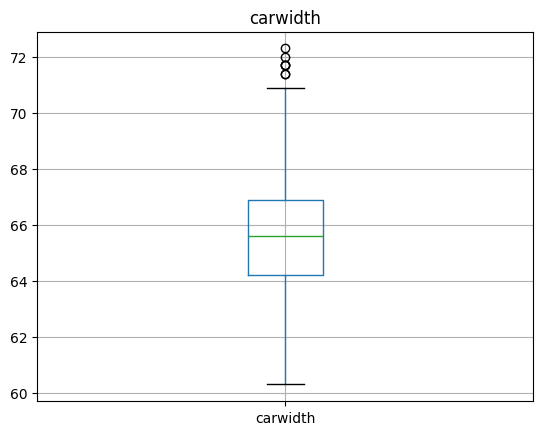

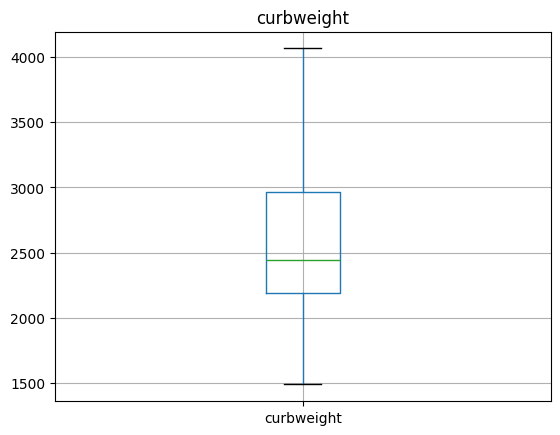

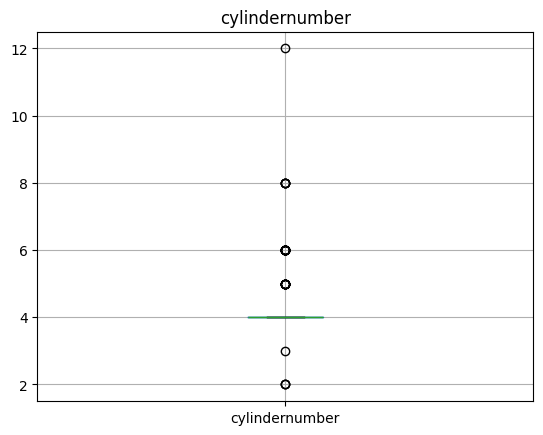

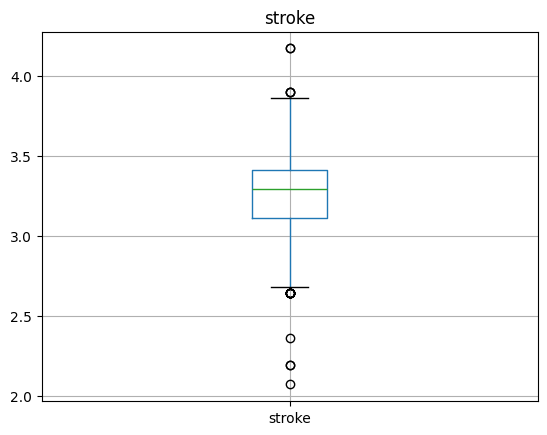

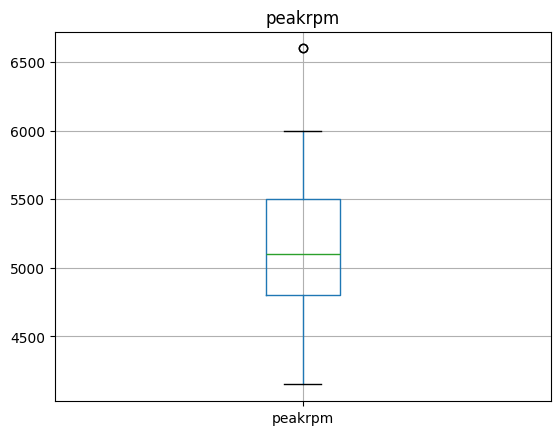

In [107]:
for col in numerical_features:
    plt.figure()
    cars.boxplot(column=col)
    plt.title(col)
    plt.show()

❓ **Soru (Sayısal sütunlara odaklanın)** ❓

Araba veri kümesinin sayısal sütunlarını `cars_num` içinde saklayın.

In [108]:
###########################
# Manuel çözüm            # - pek akıllıca değil
###########################

# num_features = ["carwidth", "curbweight", "cylindernumber", "stroke", "peakrpm"]
# cars_num = X[num_features]

# Bu, sayısal feature’ları seçmenin bir yolu...
# Ama pek akıllıca değil...

###########################
# Zarif çözüm             # - çok daha iyi
###########################

cars_num = X.select_dtypes(exclude=['object']) # yalnızca sayısal feature’ları seçiyoruz
cars_num


,carwidth,curbweight,cylindernumber,stroke,peakrpm
0,64.10000,2548.0,4,2.68,5000.0
2,65.50000,2823.0,6,3.47,5000.0
3,65.88794,2337.0,4,3.40,5500.0
4,66.40000,2824.0,5,3.40,5500.0
5,66.30000,2507.0,5,3.40,5500.0
...,...,...,...,...,...
200,68.90000,2952.0,4,3.15,5400.0
201,68.80000,3049.0,4,3.15,5300.0
202,68.90000,3012.0,6,2.87,5500.0
203,68.90000,3217.0,6,3.40,4800.0


❓ **Soru (Sağlam Ölçeklendirici)** ❓

👨🏻‍🏫 Tüm sayısal özellikleri sağlam bir şekilde ölçeklendirmek, hızlı ve verimli bir ölçeklendirme yöntemidir.

In [109]:
# RobustScaler oluşturma
robust_scaler = RobustScaler().set_output(transform='pandas')

# Feature’ları ölçekleme ve saklama
cars_num_scaled = robust_scaler.fit_transform(cars_num)

# Ölçeklenmiş feature’ları gösterme
cars_num_scaled

,carwidth,curbweight,cylindernumber,stroke,peakrpm
0,-0.555556,0.135659,0.0,-2.033333,-0.142857
2,-0.037037,0.490956,2.0,0.600000,-0.142857
3,0.106644,-0.136951,0.0,0.366667,0.571429
4,0.296296,0.492248,1.0,0.366667,0.571429
5,0.259259,0.082687,1.0,0.366667,0.571429
...,...,...,...,...,...
200,1.222222,0.657623,0.0,-0.466667,0.428571
201,1.185185,0.782946,0.0,-0.466667,0.285714
202,1.222222,0.735142,2.0,-1.400000,0.571429
203,1.222222,1.000000,2.0,0.366667,-0.428571


## (1.5) Kategorik özelliklerin kodlanması (Encoding categorical features)

❓ **Soru (Kategorik sütunlara odaklanın)** ❓

Arabalar veri kümesinin kategorik sütunlarını `cars_categorical` içinde saklayın.

In [110]:
# Manuel çözüm --> pek akıllıca değil

# categorical_features = ["aspiration", "enginetype"]
# cars_categorical = X[categorical_features]

# Zarif çözüm --> çok daha iyi
cars_categorical = X.select_dtypes(include=['object']) # yalnızca kategorik feature’ları seçiyoruz
cars_categorical

,aspiration,enginetype
0,std,dohc
2,std,ohcv
3,std,ohc
4,std,ohc
5,std,ohc
...,...,...
200,std,ohc
201,turbo,ohc
202,std,ohcv
203,turbo,ohc


❓ **Soru: Kategorik özellikleri kodlarsak, beklenen sütun sayısı kaçtır?** ❓

❓ **Soru (OneHotEncoder): Kategorik feature’ları encode edin** ❓

<details>
    <summary><i>İpuçları</i></summary>
    
- Bir kategorik feature binary ise bir sütunu drop edin
- Tam matrisler kullanın (Sklearn estimator’ları sparse matrix’leri anlayamaz)
- Sonuçları `encoded_features` adlı bir Pandas DataFrame içine kaydedin
    - 💡 OHE bir DataFrame’e fit edildikten sonra, yeni sütun adlarına _`get_features_names_out()`_ ile erişebilirsiniz
    
</details>

In [111]:
cars["aspiration"] = cars["aspiration"].map({"std": 0, "turbo": 1}).astype("Int64")

In [112]:
cars = pd.get_dummies(cars, columns=["enginetype"], drop_first=True)

In [113]:
bool_cols = cars.select_dtypes(include="bool").columns
cars[bool_cols] = cars[bool_cols].astype(int)

In [114]:
cars.head()

,aspiration,carwidth,curbweight,cylindernumber,stroke,peakrpm,price,enginetype_dohcv,enginetype_l,enginetype_ohc,enginetype_ohcf,enginetype_ohcv,enginetype_rotor
0,0,64.10000,2548.0,4,2.68,5000.0,expensive,0,0,0,0,0,0
2,0,65.50000,2823.0,6,3.47,5000.0,expensive,0,0,0,0,1,0
3,0,65.88794,2337.0,4,3.40,5500.0,expensive,0,0,1,0,0,0
4,0,66.40000,2824.0,5,3.40,5500.0,expensive,0,0,1,0,0,0
5,0,66.30000,2507.0,5,3.40,5500.0,expensive,0,0,1,0,0,0


## (1.6) Önceden işlenmiş tüm özellikleri birleştirme $X_{preprocessed}$ (Concatenating all the preprocessed features together )

❓ **Soru (önceden işlenmiş tüm özellikleri bir araya getirerek)** ❓

`cars_num_scaled` ve `encoded_features` öğelerini `X_preprocessed` öğesinde birleştirin.

In [115]:
# SENİN KODUN BURAYA
X_preprocessed = pd.concat([
    cars[['aspiration', 'enginetype_dohcv', 'enginetype_l', 'enginetype_ohc', 'enginetype_ohcf', 'enginetype_ohcv', 'enginetype_rotor']],
    cars_num_scaled],
    axis=1
)


In [116]:
X_preprocessed.head()

,aspiration,enginetype_dohcv,enginetype_l,enginetype_ohc,enginetype_ohcf,enginetype_ohcv,enginetype_rotor,carwidth,curbweight,cylindernumber,stroke,peakrpm
0,0,0,0,0,0,0,0,-0.555556,0.135659,0.0,-2.033333,-0.142857
2,0,0,0,0,0,1,0,-0.037037,0.490956,2.0,0.600000,-0.142857
3,0,0,0,1,0,0,0,0.106644,-0.136951,0.0,0.366667,0.571429
4,0,0,0,1,0,0,0,0.296296,0.492248,1.0,0.366667,0.571429
5,0,0,0,1,0,0,0,0.259259,0.082687,1.0,0.366667,0.571429


## (1.7) Hedefin kodlanması (Encoding the target )

❓ **Soru (Kategorik target’ın encode edilmesi)** ❓

Target değişkenini 📚[***LabelEncoder***](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) kullanarak encode edin.

In [117]:
# SENİN KODUN BURAYA
le = LabelEncoder()
cars["price"] = le.fit_transform(cars["price"])

In [118]:
y = cars['price']
y

0      1
2      1
3      1
4      1
5      1
      ..
200    1
201    1
202    1
203    1
204    1
Name: price, Length: 191, dtype: int64

# (2) 🏋🏻‍♂️ Modelleme (Modeling (Logistic Regression))

🎯 Amacımız, bazı özelliklere dayanarak bir arabanın pahalı mı yoksa ucuz mu olacağını tahmin etmektir.

## (2.0) Cross-Validation

👩‍🏫 Machine Learning’de, farklı modelleri karşılaştırmak istediğinizde, Cross Validation her bir alt modelin performansını kabaca ve sağlam bir şekilde değerlendirmek için kullanılan güçlü bir yöntemdir.

 **Soru (Çapraz Doğrulama)(CrossValidation)** ❓

Bu veri kümesi için LogisticRegression'ın potansiyel performansı nedir?

In [119]:
# SENİN KODUN BURAYA
from sklearn.model_selection import cross_val_score
model = LogisticRegression()

cross_score = cross_val_score(model, X_preprocessed, y, cv=5, scoring='roc_auc_ovo').mean()
cross_score


0.970272601794341

- 🚀 Bu doğruluk umut verici, hadi daha da ileri gidelim!
- 🗣 İyi bir Regression / Classification modelinin ne olduğunu `Performance Metrics` ünitesinde tartışacağız.

## (2.1) Holdout Method

❓ **Soru (Holdout): Dataset’inizi %70 / %30 oranında train / test olarak ayırın** ❓

<details>
    <summary><i>İpucu</i></summary>

- Binary bir target için aslında `LabelEncoder` kullanmanız gerekmez.
    - Sklearn, binary bir target’ı algılayacak kadar akıllıdır.
    
</details>

In [120]:
# SENİN KODUN BURAYA
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_preprocessed, y,
    test_size=0.3,
    random_state=1
)

In [121]:
train_ratio = y_train.mean()
test_ratio = y_test.mean()
print(f"  Train class 1 ratio: {train_ratio:.3f}")
print(f"  Test  class 1 ratio: {test_ratio:.3f}")

  Train class 1 ratio: 0.647
  Test  class 1 ratio: 0.534


## (2.2) Training and evaluating

❓ **Soru: Lojistik regresyon modelini Train/Evaluate** 

In [122]:
# Logistic Regression modelini oluşturma
logreg = LogisticRegression(max_iter=100)

# Modeli eğitme
logreg.fit(X_train, y_train)

# Modeli değerlendirme
logreg.score(X_test, y_test)

0.8448275862068966

In [232]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000)

In [233]:
logreg.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## (2.3) Predicting

❓ **Soru (Yeni bir “nokta”yı tahmin etme)** ❓

ML algoritmanız (az önce eğittiğiniz Logistic Regression), aşağıdaki özelliklere sahip bir arabanın pahalı olacağını düşünüyor mu?

In [193]:
new_car = pd.DataFrame(columns=X.columns)
new_car.loc[0] = ['std', 65.88793969849246, 1874.0, 'ohc', 'four', 3.11, 5400.0]
new_car

,aspiration,carwidth,curbweight,enginetype,cylindernumber,stroke,peakrpm
0,std,65.88794,1874.0,ohc,four,3.11,5400.0


> 👨🏻‍🏫 **Bir tahmin yapabilmek için, bu yeni aracın training set üzerinde uygulanan dönüşümlerin aynısından geçmesi gerekir!**

🌠 Bu recap’in büyük resmine [buradan](https://wagon-public-datasets.s3.amazonaws.com/05-Machine-Learning/prepare_dataset_fit_transform.png) göz atın!

In [194]:
# 0 - Anormal verilerin düzeltilmesi

new_car.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1 entries, 0 to 0
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   aspiration      1 non-null      object 
 1   carwidth        1 non-null      float64
 2   curbweight      1 non-null      float64
 3   enginetype      1 non-null      object 
 4   cylindernumber  1 non-null      object 
 5   stroke          1 non-null      float64
 6   peakrpm         1 non-null      float64
dtypes: float64(4), object(3)
memory usage: 64.0+ bytes


In [195]:
new_car['cylindernumber'] = new_car['cylindernumber'].map({'four':4})

In [196]:
new_car['cylindernumber'] = new_car['cylindernumber'].astype(int)

In [197]:
new_car.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1 entries, 0 to 0
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   aspiration      1 non-null      object 
 1   carwidth        1 non-null      float64
 2   curbweight      1 non-null      float64
 3   enginetype      1 non-null      object 
 4   cylindernumber  1 non-null      int64  
 5   stroke          1 non-null      float64
 6   peakrpm         1 non-null      float64
dtypes: float64(4), int64(1), object(2)
memory usage: 64.0+ bytes


In [218]:
new_car_num = new_car.select_dtypes(exclude=["object"])
new_car_num

,carwidth,curbweight,cylindernumber,stroke,peakrpm
0,65.88794,1874.0,4,3.11,5400.0


In [224]:
from sklearn.preprocessing import RobustScaler

num_cols = ["carwidth","curbweight","cylindernumber","stroke","peakrpm"]

# 1️⃣ cars datası ile FIT
robust_scaler = RobustScaler().set_output(transform="pandas")
robust_scaler.fit(cars[num_cols])

# 2️⃣ new_car'a SADECE transform
new_car_num_scaled = robust_scaler.transform(new_car[num_cols])

new_car_num_scaled

,carwidth,curbweight,cylindernumber,stroke,peakrpm
0,0.106644,-0.735142,0.0,-0.6,0.428571


In [225]:
# 2 - Kategorik özelliklerin kodlanması
new_car_cat = new_car.select_dtypes(include=["object"])

In [226]:
new_car_cat_dum = pd.get_dummies(new_car_cat, drop_first=False)
new_car_cat_dum = new_car_cat_dum.astype(int)
new_car_cat_dum


,aspiration_std,enginetype_ohc
0,1,1


In [227]:
new_car_cat_dum.columns = new_car_cat_dum.columns.str.replace("_std", "", regex=False)

In [228]:
new_car_cat_dum

,aspiration,enginetype_ohc
0,1,1


In [229]:
# 3 - Sayısal özellikleri ve kategorik özellikleri bir araya getirme
new_car_prepared = pd.concat([new_car_num_scaled, new_car_cat_dum], axis=1)

In [230]:
new_car_prepared

,carwidth,curbweight,cylindernumber,stroke,peakrpm,aspiration,enginetype_ohc
0,0.106644,-0.735142,0.0,-0.6,0.428571,1,1


In [235]:
new_car_prepared = new_car_prepared.reindex(columns=X_train.columns, fill_value=0)
new_car_prepared

,aspiration,enginetype_dohcv,enginetype_l,enginetype_ohc,enginetype_ohcf,enginetype_ohcv,enginetype_rotor,carwidth,curbweight,cylindernumber,stroke,peakrpm
0,1,0,0,1,0,0,0,0.106644,-0.735142,0.0,-0.6,0.428571


In [236]:
# 4 - Tahmin

prediction = logreg.predict(new_car_prepared)
prediction

array([0])

In [237]:
proba = logreg.predict_proba(new_car_prepared)
proba

array([[0.51877925, 0.48122075]])

# (3) 🧑🏿‍🏫 Veri Sızıntısı Hakkında Uyarı (Warning about Data Leakage)

<img src="https://wagon-public-datasets.s3.amazonaws.com/05-Machine-Learning/cross_validation_data_leakage.png"  width=600>

🏁 Tebrikler! Artık veri seti hazırlama konusunda uzmansınız!
